In [1]:
#libary 
import pandas as pd 
import numpy as np 
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import seaborn as sns
import matplotlib.patheffects as path_effects



In [2]:
#df
df_values=pd.read_csv('train_values.csv')
df_labels=pd.read_csv('train_labels.csv')
df=pd.merge(df_values,df_labels,on='building_id')
df.set_index('building_id',inplace=True)
df


,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
building_id,,,,,,,,,,,,,,,,,,,,,
802906,6,487,12198,2,30,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
28830,8,900,2812,2,10,8,7,o,r,n,...,0,0,0,0,0,0,0,0,0,2
94947,21,363,8973,2,10,5,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
590882,22,418,10694,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
201944,11,131,1488,3,30,8,9,t,r,n,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
688636,25,1335,1621,1,55,6,3,n,r,n,...,0,0,0,0,0,0,0,0,0,2
669485,17,715,2060,2,0,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,3
602512,17,51,8163,3,55,6,7,t,r,q,...,0,0,0,0,0,0,0,0,0,3


In [3]:
#missing_data
df.isnull().sum().sort_values().loc[lambda x: x > 0]
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values()
print(missing_percent)


geo_level_1_id                            0.0
geo_level_2_id                            0.0
geo_level_3_id                            0.0
count_floors_pre_eq                       0.0
age                                       0.0
area_percentage                           0.0
height_percentage                         0.0
land_surface_condition                    0.0
foundation_type                           0.0
roof_type                                 0.0
ground_floor_type                         0.0
other_floor_type                          0.0
position                                  0.0
plan_configuration                        0.0
has_superstructure_adobe_mud              0.0
has_superstructure_mud_mortar_stone       0.0
has_superstructure_stone_flag             0.0
has_superstructure_cement_mortar_stone    0.0
has_superstructure_mud_mortar_brick       0.0
has_superstructure_cement_mortar_brick    0.0
has_superstructure_timber                 0.0
has_superstructure_bamboo         

In [4]:
#basic_information
df.info(memory_usage='deep')
df.describe()

<class 'pandas.DataFrame'>
Index: 260601 entries, 802906 to 747594
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   geo_level_1_id                          260601 non-null  int64
 1   geo_level_2_id                          260601 non-null  int64
 2   geo_level_3_id                          260601 non-null  int64
 3   count_floors_pre_eq                     260601 non-null  int64
 4   age                                     260601 non-null  int64
 5   area_percentage                         260601 non-null  int64
 6   height_percentage                       260601 non-null  int64
 7   land_surface_condition                  260601 non-null  str  
 8   foundation_type                         260601 non-null  str  
 9   roof_type                               260601 non-null  str  
 10  ground_floor_type                       260601 non-null  str  
 11  other_floor

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,0.034332,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,0.182081,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [5]:
#Feature Engineering
super_cols = [col for col in df.columns if col.startswith("has_superstructure_")]
df["n_materials"] = df[super_cols].sum(axis=1)
df["age_material_score"] = df["age"] * df["n_materials"]

df["slenderness"] = df["height_percentage"] / (df["area_percentage"] + 1)
df["height_to_total"] = df["height_percentage"] / (df["height_percentage"] + df["area_percentage"])


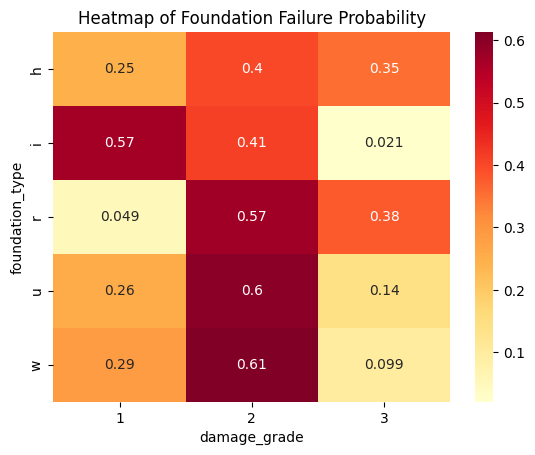

In [6]:
#foundation
crosstab_result=pd.crosstab(df["foundation_type"], df["damage_grade"], normalize="index")
sns.heatmap(crosstab_result, annot=True, cmap="YlOrRd")
plt.title("Heatmap of Foundation Failure Probability")
plt.show()

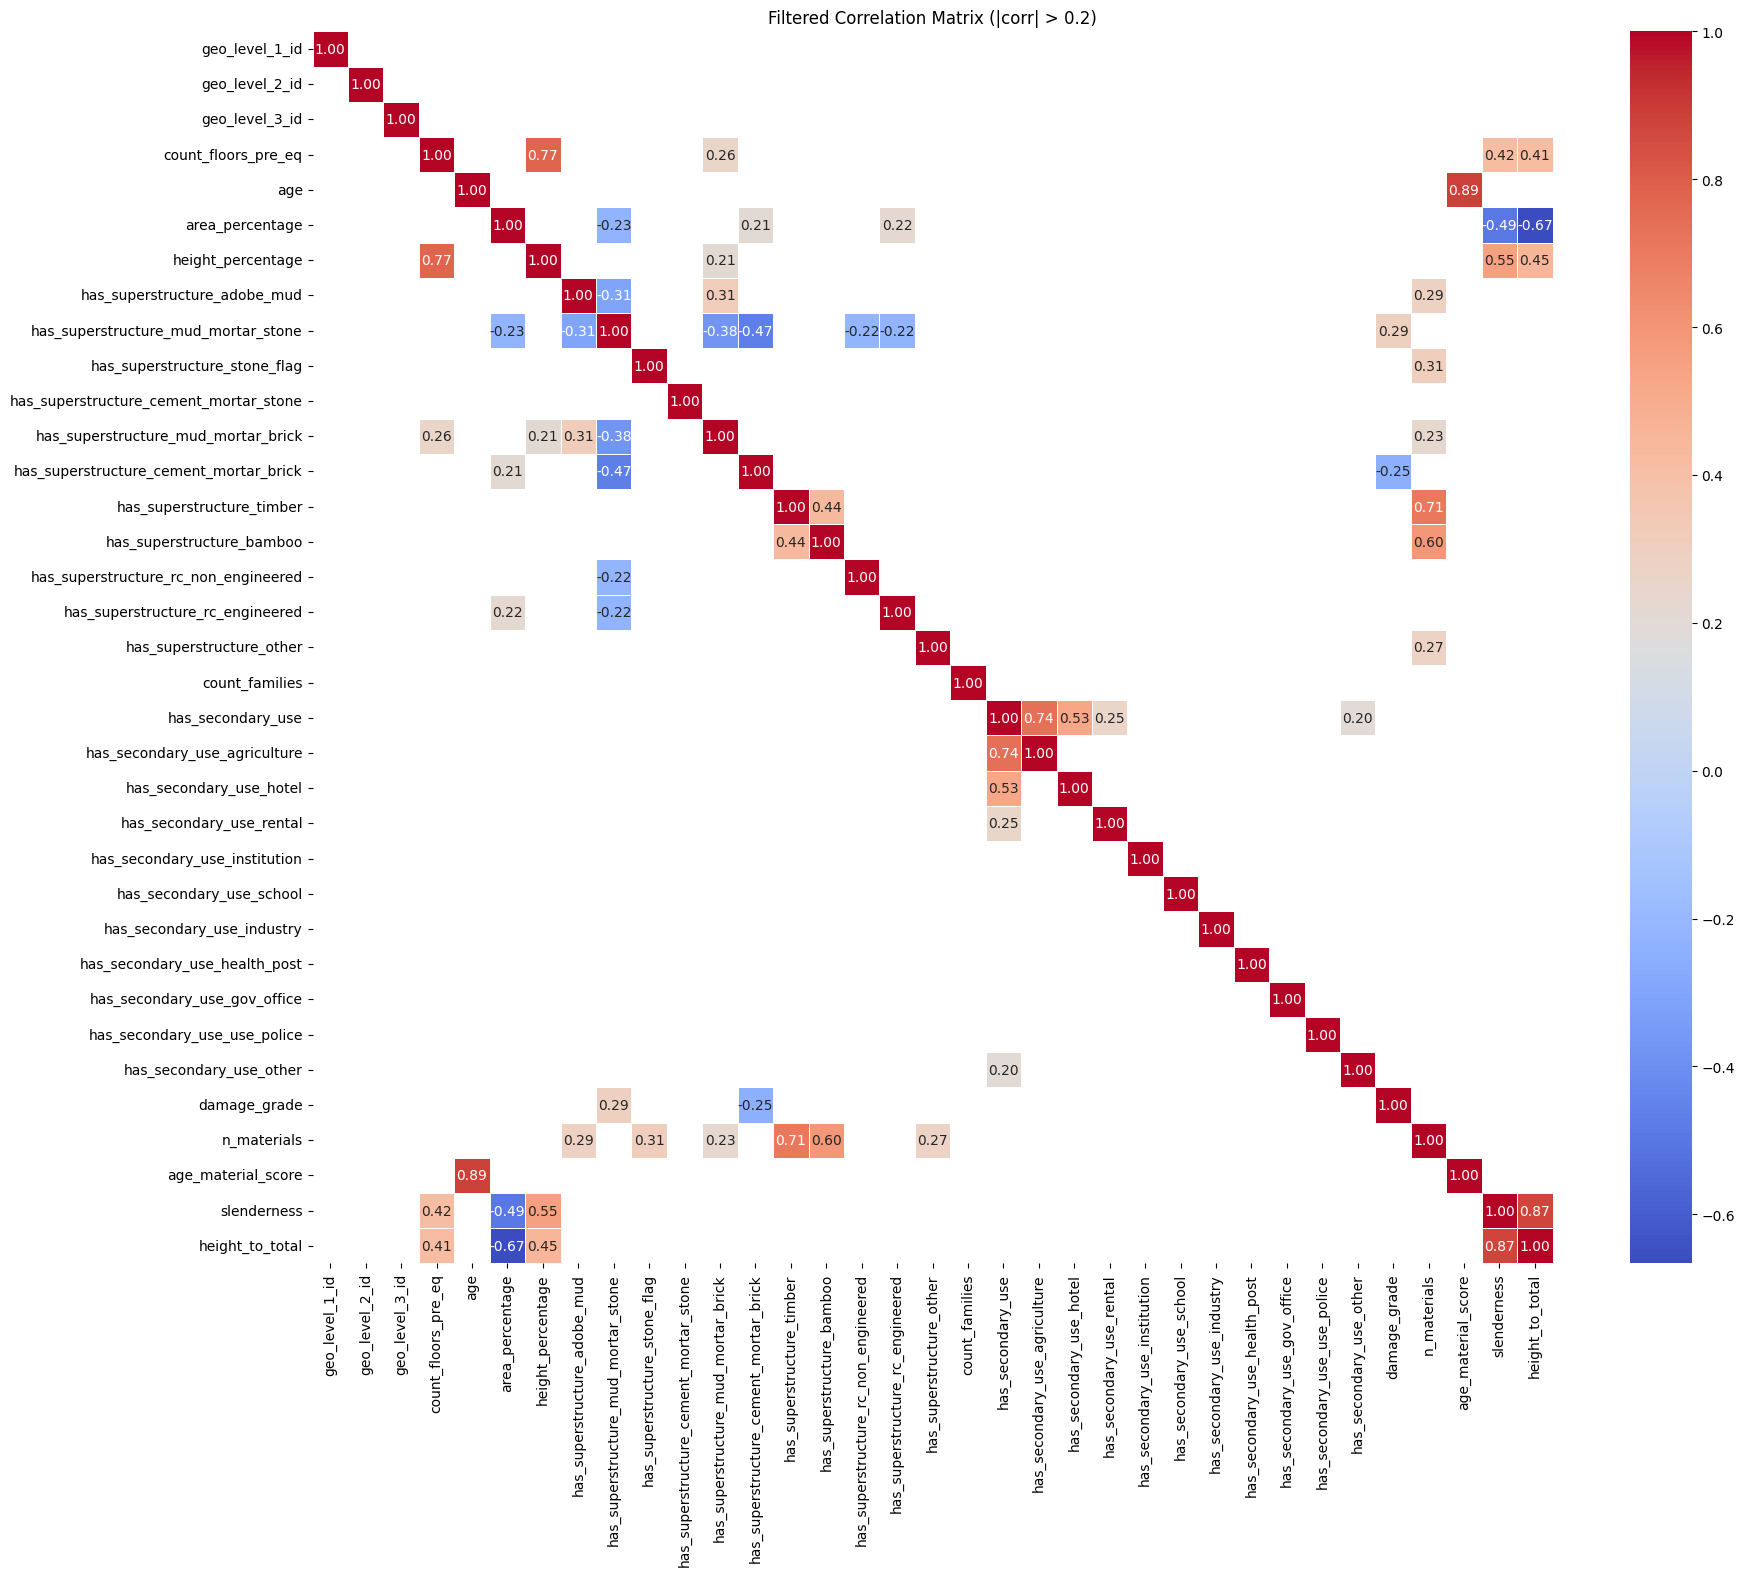

In [7]:
#Correlation Matrix
numeric_cols = df.select_dtypes(include=['number']).columns
correlationMatrix=df[numeric_cols].corr()
filtered_corr = correlationMatrix[(correlationMatrix >= 0.2) | (correlationMatrix <= -0.2)]
plt.figure(figsize=(20, 16))
sns.heatmap(filtered_corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Filtered Correlation Matrix (|corr| > 0.2)")
plt.xticks(rotation=90)
plt.show()



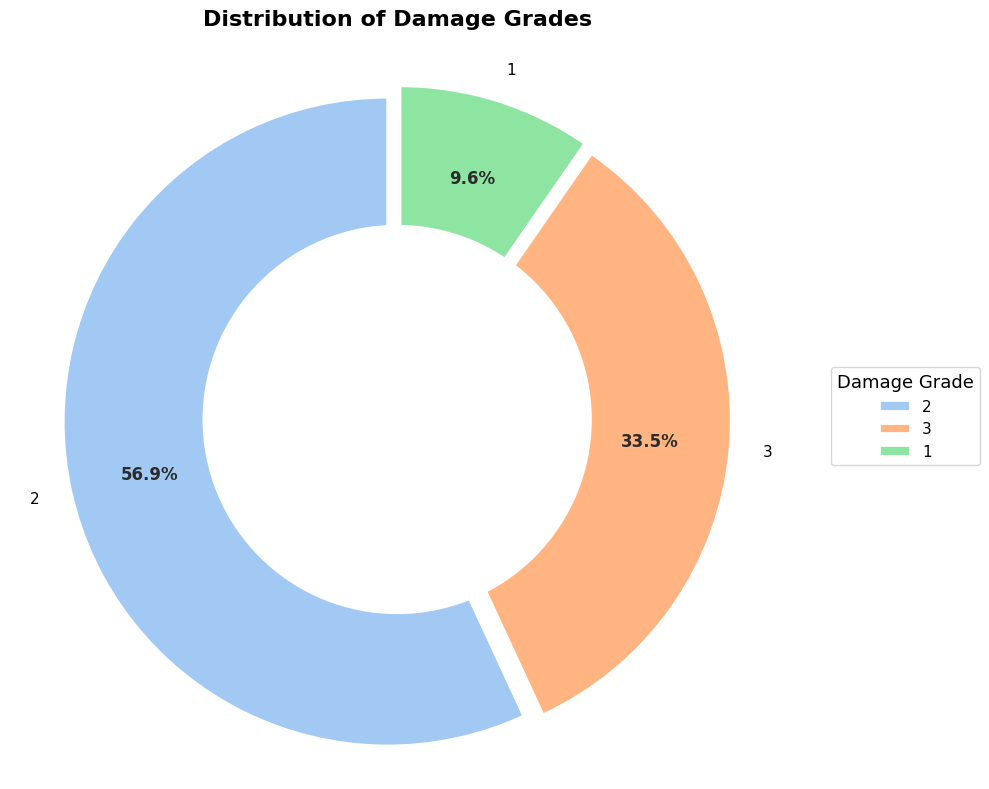

In [8]:
#Data distribution
class_distribution = df['damage_grade'].value_counts()
plt.figure(figsize=(10, 8), dpi=100)
colors = sns.color_palette("pastel")[0:len(class_distribution)]
wedges, texts, autotexts = plt.pie(
    class_distribution.values,
    labels=class_distribution.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.75,
    explode=[0.03] * len(class_distribution),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 11}
)
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
for autotext in autotexts:
    autotext.set_color('#2b2b2b')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
plt.title('Distribution of Damage Grades', fontsize=16, fontweight='bold', pad=20)
plt.legend(
    wedges, 
    class_distribution.index,
    title="Damage Grade",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    fontsize=11,
    title_fontsize=13
)
plt.axis('equal') 
plt.tight_layout()
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['damage_grade'])
y = df['damage_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
from catboost import CatBoostClassifier

# تعریف ستون‌های جغرافیایی
geo_cols = ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']
X_train[geo_cols] = X_train[geo_cols].astype(str)
X_test[geo_cols] = X_test[geo_cols].astype(str)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features_indices = [X_train.columns.get_loc(col) for col in cat_cols]

# تعریف مدل
cb_model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',
    class_weights=[1.5, 0.8, 1.2], 
    learning_rate=0.05,   
    iterations=1500,     
    depth=6,              
    random_seed=42,
    verbose=100 
)
cb_model.fit(
    X_train, y_train,
    cat_features=categorical_features_indices,
    eval_set=(X_test, y_test),
    early_stopping_rounds=100, 
    use_best_model=True
)



C:\Users\savan\AppData\Local\Temp\ipykernel_18336\1477633615.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


0:	learn: 0.6716008	test: 0.6861371	best: 0.6861371 (0)	total: 399ms	remaining: 9m 57s


KeyboardInterrupt: 

In [ ]:
cb_model.save_model('catboost_earthquake_model.cbm')

In [21]:
loaded_model = CatBoostClassifier()
loaded_model.load_model('catboost_earthquake_model.cbm')

CatBoostClassifier(class_weights=[1.5, 0.8, 1.2], depth=6, eval_metric='TotalF1', iterations=1500, learning_rate=0.05, loss_function='MultiClass', od_type='Iter', od_wait=100, random_seed=42, use_best_model=True, verbose=100)

=== Classification Report ===
              precision    recall  f1-score   support

           1     0.5913    0.7079    0.6443      5025
           2     0.7881    0.7506    0.7689     29652
           3     0.7065    0.7235    0.7149     17444

    accuracy                         0.7374     52121
   macro avg     0.6953    0.7273    0.7094     52121
weighted avg     0.7418    0.7374    0.7388     52121



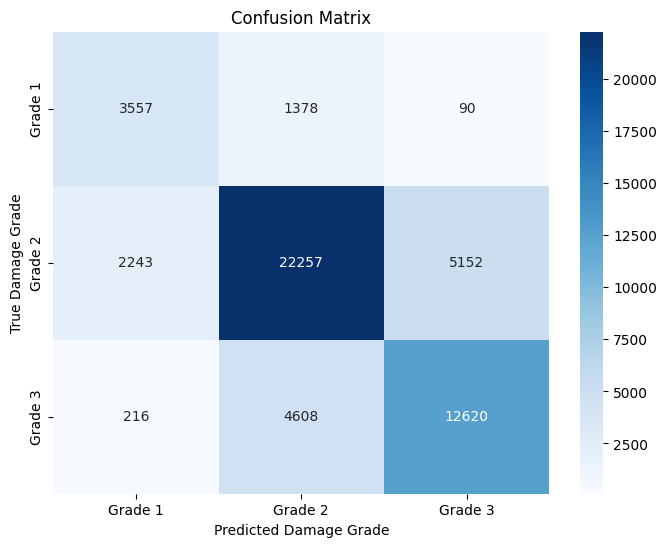

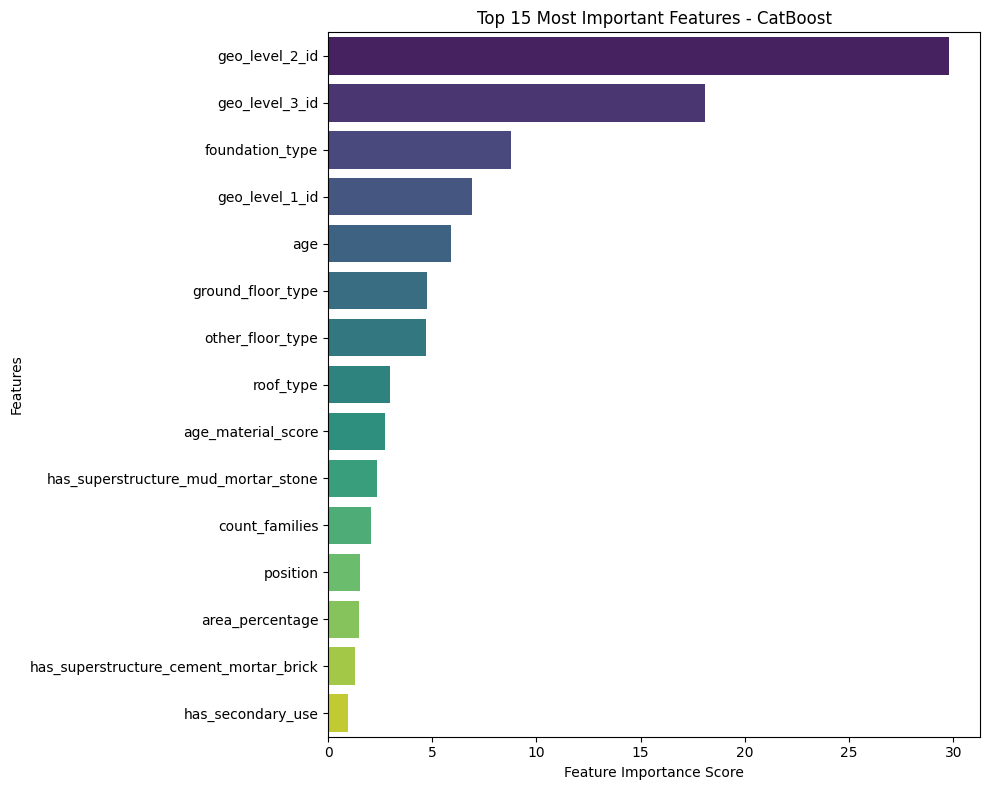

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = loaded_model.predict(X_test)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Grade 1', 'Grade 2', 'Grade 3'], 
            yticklabels=['Grade 1', 'Grade 2', 'Grade 3'])
plt.title('Confusion Matrix')
plt.ylabel('True Damage Grade')
plt.xlabel('Predicted Damage Grade')
plt.show()
feature_importance = loaded_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[::-1][:15] # 15 ویژگی برتر

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance[sorted_idx], y=X_train.columns[sorted_idx], palette="viridis")
plt.title('Top 15 Most Important Features - CatBoost')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
